# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Muhammad Fasya Atthaya Rosyada | 5054251006 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [3]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('bankruptcy.csv')

print("Jumlah baris dan kolom:", df.shape)
print("Tipe data:")
df.info()

print("Statistik deskriptif:")
print(df.describe())   
print("Jumlah missing value:", df.isnull().sum().sum())

Jumlah baris dan kolom: (6819, 96)
Tipe data:
<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-nul

C:\Users\Pongo\AppData\Local\Temp\ipykernel_5324\1465390757.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Bankrupt?', palette='Set2')


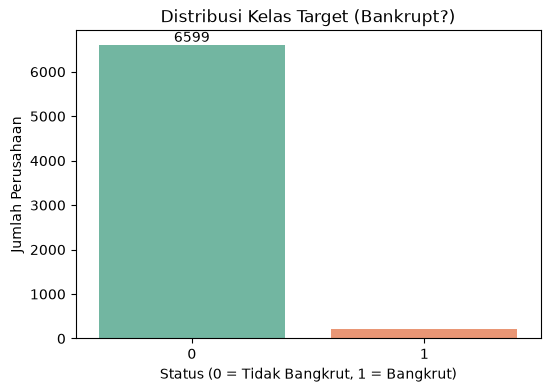

Persentase Kelas:
 Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


In [4]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Bankrupt?', palette='Set2')
plt.title('Distribusi Kelas Target (Bankrupt?)')
plt.xlabel('Status (0 = Tidak Bangkrut, 1 = Bangkrut)')
plt.ylabel('Jumlah Perusahaan')
plt.bar_label(ax.containers[0])
plt.show()

print("Persentase Kelas:\n", df['Bankrupt?'].value_counts(normalize=True) * 100)

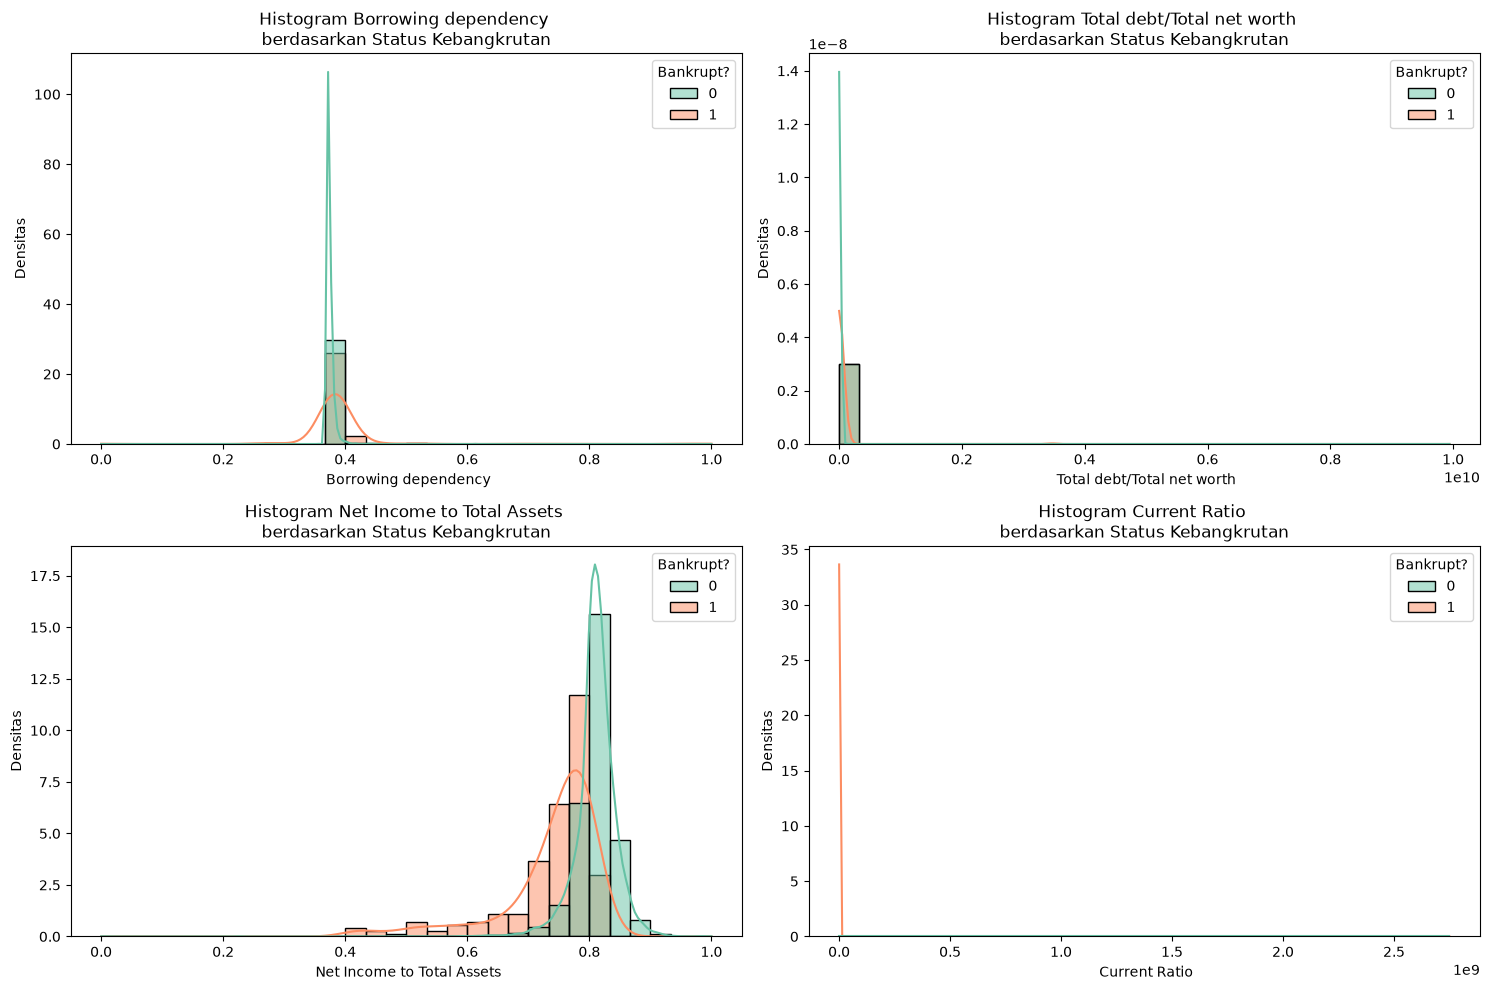

In [5]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
fitur_pilihan = [' Borrowing dependency', ' Total debt/Total net worth', ' Net Income to Total Assets', ' Current Ratio']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(fitur_pilihan):
    plt.subplot(2, 2, i+1)
    sns.histplot(data=df, x=feature, hue='Bankrupt?', kde=True, palette='Set2', bins=30, stat="density", common_norm=False)
    plt.title(f'Histogram {feature.strip()} \nberdasarkan Status Kebangkrutan')
    plt.ylabel('Densitas')
    
plt.tight_layout()
plt.show()

--- Top 10 Fitur Berkorelasi POSITIF (Meningkatkan risiko bangkrut) ---
Debt ratio %                           0.250161
Current Liability to Assets            0.194494
Borrowing dependency                   0.176543
Current Liability to Current Assets    0.171306
Liability to Equity                    0.166812
Current Liabilities/Equity             0.153828
Current Liability to Equity            0.153828
Liability-Assets Flag                  0.139212
Total expense/Assets                   0.139049
Equity to Long-term Liability          0.139014
Name: Bankrupt?, dtype: float64

--- Top 10 Fitur Berkorelasi NEGATIF (Menurunkan risiko bangkrut) ---
Net Income to Total Assets                                -0.315457
ROA(A) before interest and % after tax                    -0.282941
ROA(B) before interest and depreciation after tax         -0.273051
ROA(C) before interest and depreciation before interest   -0.260807
Net worth/Assets                                          -0.250161
Persi

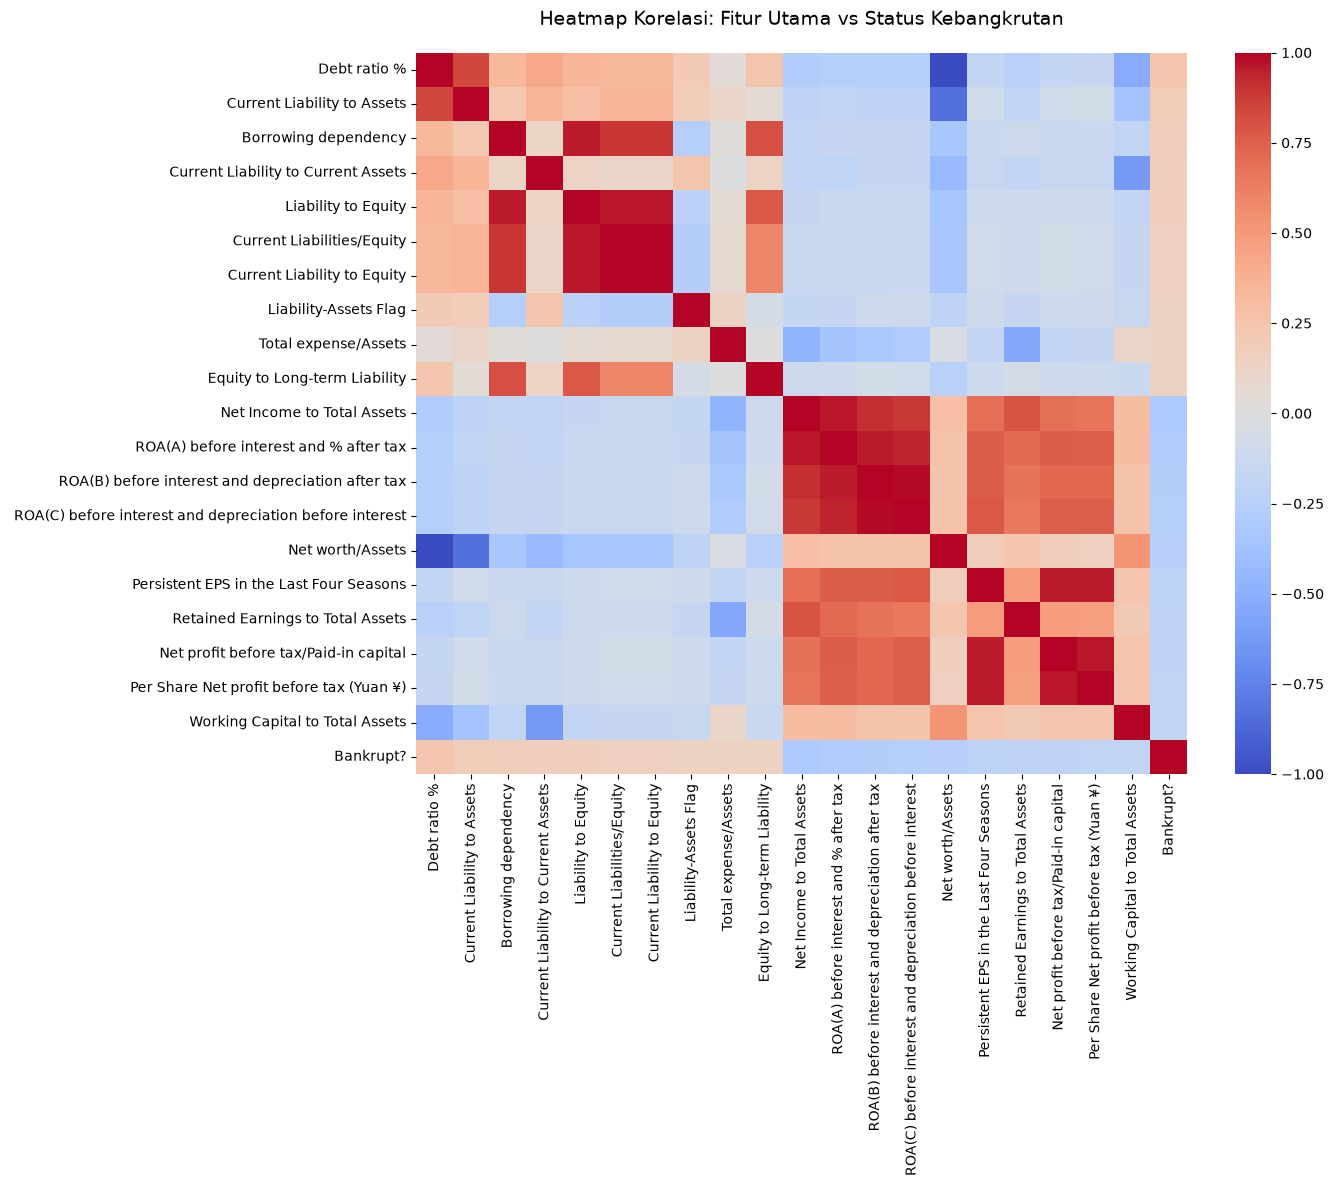

In [6]:
korelasi = df.corr()
top_pos_corr = korelasi['Bankrupt?'].sort_values(ascending=False)[1:11] # [1:11] untuk melewati 'Bankrupt?' itu sendiri
top_neg_corr = korelasi['Bankrupt?'].sort_values(ascending=True)[:10]

print("--- Top 10 Fitur Berkorelasi POSITIF (Meningkatkan risiko bangkrut) ---")
print(top_pos_corr)
print("\n--- Top 10 Fitur Berkorelasi NEGATIF (Menurunkan risiko bangkrut) ---")
print(top_neg_corr)

fitur_korelasi_tinggi = list(top_pos_corr.index) + list(top_neg_corr.index) + ['Bankrupt?']
df_heatmap = df[fitur_korelasi_tinggi]

plt.figure(figsize=(14, 12))
sns.heatmap(df_heatmap.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi: Fitur Utama vs Status Kebangkrutan', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [7]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print("Total missing values yang perlu ditangani:", df.isnull().sum().sum())

Total missing values yang perlu ditangani: 0


In [8]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.

In [9]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dimensi X_train:", X_train.shape)
print("Dimensi X_test:", X_test.shape)


Dimensi X_train: (5455, 95)
Dimensi X_test: (1364, 95)


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [10]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

y_pred_gini = dt_gini.predict(X_test)

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [11]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

y_pred_entropy = dt_entropy.predict(X_test)

## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [18]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
max_depths = [1, 2, 3, 5, 10, None]
train_accuracies = []
test_accuracies = []

for depth in max_depths:
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    train_accuracies.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, dt.predict(X_test)))

depth_labels = [str(d) if d is not None else 'None' for d in max_depths]

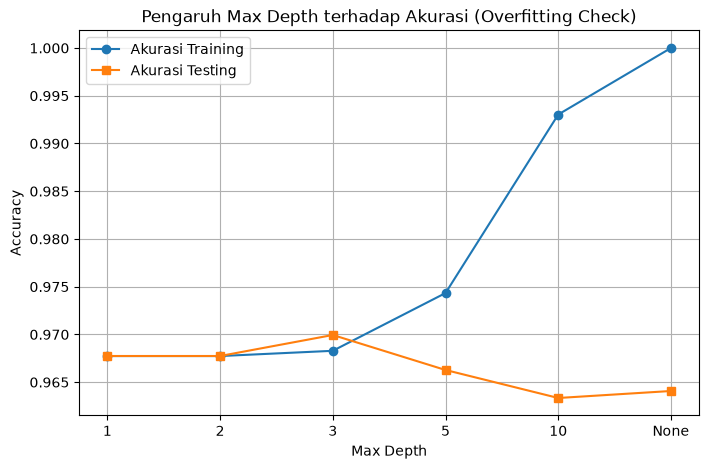

In [13]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_accuracies, label='Akurasi Training', marker='o')
plt.plot(depth_labels, test_accuracies, label='Akurasi Testing', marker='s')
plt.title('Pengaruh Max Depth terhadap Akurasi (Overfitting Check)')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 4. Evaluasi Model

In [14]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

metrics_gini = get_metrics(y_test, y_pred_gini, 'Gini')
metrics_entropy = get_metrics(y_test, y_pred_entropy, 'Entropy')

df_metrics = pd.DataFrame([metrics_gini, metrics_entropy])
display(df_metrics)

,Model,Accuracy,Precision,Recall,F1-Score
0,Gini,0.961144,0.400000,0.409091,0.404494
1,Entropy,0.964076,0.435897,0.386364,0.409639


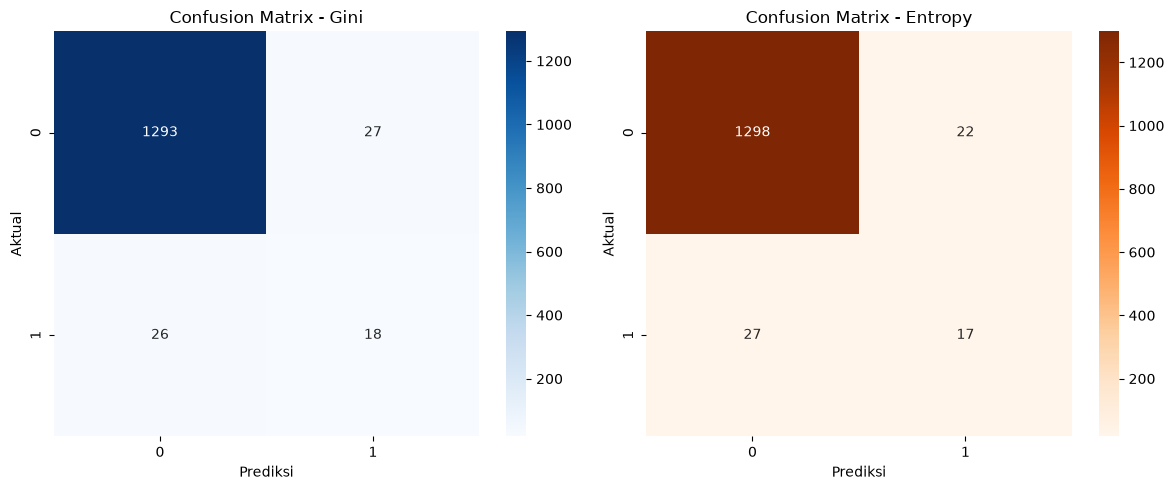

In [15]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_gini = confusion_matrix(y_test, y_pred_gini)
sns.heatmap(cm_gini, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Gini')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

cm_entropy = confusion_matrix(y_test, y_pred_entropy)
sns.heatmap(cm_entropy, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Confusion Matrix - Entropy')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

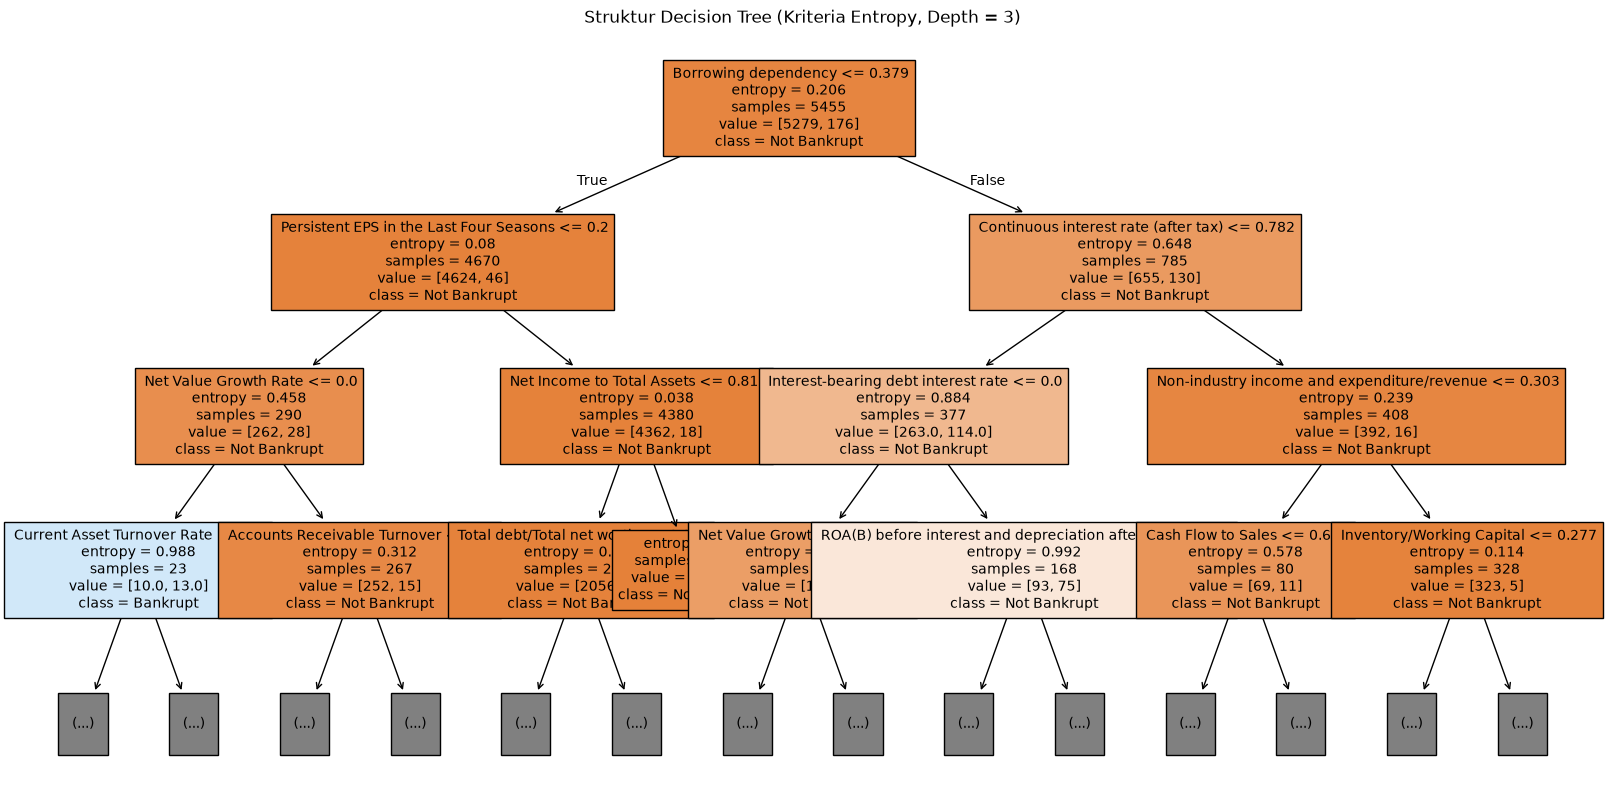

In [16]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.
plt.figure(figsize=(20,10))
plot_tree(dt_entropy, feature_names=X.columns, class_names=['Not Bankrupt', 'Bankrupt'], filled=True, max_depth=3, fontsize=10)
plt.title("Struktur Decision Tree (Kriteria Entropy, Depth = 3)")
plt.show()

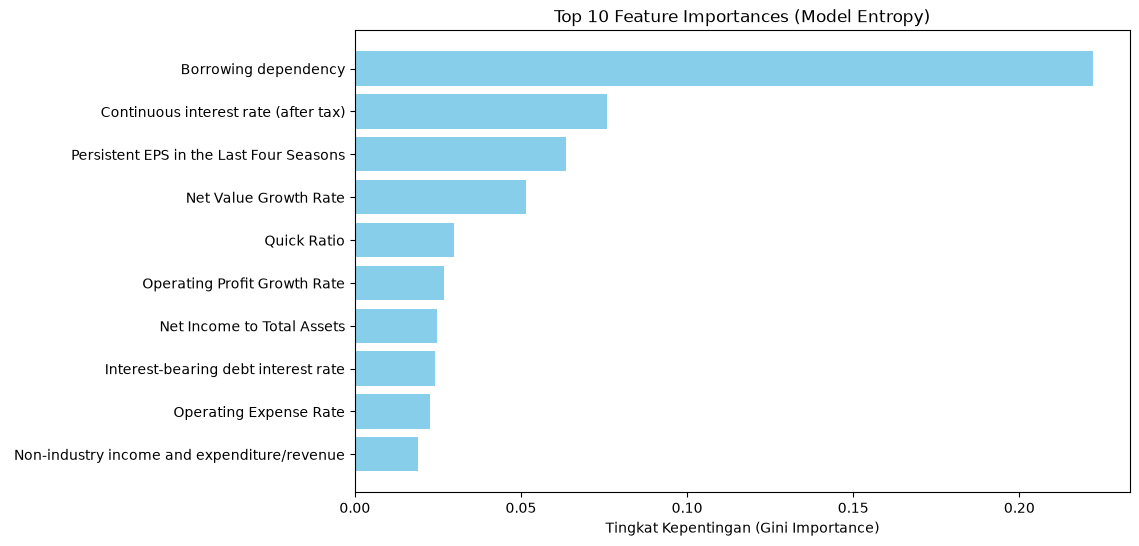

In [17]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
importances = dt_entropy.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 10
top_indices = indices[:top_n]

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), importances[top_indices], align='center', color='skyblue')
plt.yticks(range(top_n), [X.columns[i] for i in top_indices])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances (Model Entropy)')
plt.xlabel('Tingkat Kepentingan (Gini Importance)')
plt.show()

# 5. Analisis

**Perbandingan Decision Tree Gini vs Entropy:**
Berdasarkan hasil metrik evaluasi, model Decision Tree dengan kriteria *Gini Impurity* dan *Entropy* menghasilkan performa yang hampir identik (keduanya mencetak nilai *Accuracy* di kisaran 96%). Perbedaan di antara keduanya sangat tipis karena dalam dataset berskala besar, metrik Gini maupun Entropy umumnya sepakat dalam memilih fitur-fitur dominan pada node teratas. Gini sedikit lebih unggul dalam kecepatan komputasi karena tidak memerlukan operasi logaritmik, namun secara keseluruhan hasil klasifikasi keduanya tidak berbeda signifikan.

**Temuan dari Eksperimen Regularisasi (max_depth):**
Dari grafik eksperimen akurasi *Training vs Testing*, kita dapat mengamati fenomena *overfitting* yang sangat jelas. 
- Pada nilai `max_depth` yang rendah (misalnya 1, 2, atau 3), akurasi *training* dan *testing* bergerak selaras. Model memiliki kemampuan generalisasi yang baik.
- Gejala *overfitting* mulai terlihat saat `max_depth` menyentuh nilai **5 ke atas**. 
- Ciri-cirinya terlihat jelas dari kurva: akurasi *training* terus naik hingga 100% saat `max_depth` dibiarkan tanpa batas (`None`), sedangkan akurasi *testing* mulai menurun atau stagnan di kisaran 96,3%. Ini menandakan model mulai menghafal *noise* dari data latih, alih-alih mempelajari pola umum.

**Fitur yang Paling Berpengaruh (Feature Importance):**
Berdasarkan plot *Feature Importance*, fitur yang menduduki peringkat teratas adalah **Borrowing dependency**, disusul oleh **Continuous interest rate (after tax)** dan **Persistent EPS in the Last Four Seasons**. Secara fundamental keuangan, hal ini sangat logis. Perusahaan yang sangat bergantung pada pinjaman utang dan terbebani suku bunga tinggi adalah entitas yang paling berisiko mengalami insolvensi atau kebangkrutan.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

**Kesimpulan:**
Eksperimen ini menunjukkan bahwa *Decision Tree* mampu memprediksi status kebangkrutan perusahaan dengan akurasi yang tinggi (sekitar 96%). Pemilihan kriteria split (*Gini* vs *Entropy*) tidak memberikan dampak yang drastis pada performa. Namun, hal terpenting adalah rentannya model ini terhadap *overfitting* jika dibiarkan tumbuh maksimal tanpa batasan. Regularisasi menggunakan parameter `max_depth` terbukti sangat krusial. Kedalaman pohon yang ideal pada dataset ini berada pada rentang moderat (`max_depth = 2` atau `3`), yang cukup untuk menangkap pola penting tanpa menghafal data (*memorization*).

**Saran & Rekomendasi:**
1. **Penanganan Data Imbalance:** Dataset ini sangat timpang (jumlah perusahaan bangkrut sangat sedikit). Akurasi 96% berpotensi menipu (*accuracy paradox*). Eksperimen selanjutnya sangat disarankan untuk menggunakan teknik *resampling* seperti **SMOTE** atau mengatur parameter `class_weight='balanced'` agar model lebih sensitif terhadap kelas minoritas.
2. **Pruning Lanjutan:** Daripada hanya menggunakan *Pre-pruning* (`max_depth`), akan menarik untuk mencoba *Cost-Complexity Pruning* (`ccp_alpha`) yang memungkinkan pohon tumbuh penuh lalu memangkas cabang yang tidak signifikan.
3. **Eksplorasi Hyperparameter Lain:** Dapat dicoba variasi parameter lain seperti `min_samples_split` atau `min_samples_leaf` untuk menghasilkan pohon yang lebih stabil dan tidak terlalu spesifik pada data latih.